# Ft Huachuca Biomass Data
The data was cleand and had QAQC performed in a previous notebook. This notebook picks up investigating the biomass outputs to make sure that they are reasonable and valid.

First, the data is loaded and cleaned following steps developed previously.

In [1]:
# import calc_biomass package
import sys
sys.path.append('../')
from calc_biomass import manage_data

import pandas as pd
import matplotlib.pyplot as plt

# Jupyter magic to make plots display interactive
# must install ipympl (Ipython-matplotlib) and nodejs
from ipywidgets.embed import embed_minimal_html
%matplotlib widget

In [2]:
def calc_edrc(df):
    # df is one tree id from a single plot
    # for trees with only one tree id, the sqrt(d2) == d
    dbh = (sum(df['dbh']**2))**0.5
    
    other_val = df.max()

    newdf = pd.DataFrame()
    newdf.loc[1,'DBH'] = dbh
    newdf.loc[1, df.columns] = other_val

    return newdf

In [16]:
# load data
data = manage_data.LoadData()
data.load_data(data.data_path)

# calculate ERC
data.df.rename(columns={'Final DBH/DRC':'dbh', 'spp':'Species','Species Code':'spp'}, inplace=True)
data.df = data.df.groupby(['Plot', 'Tree Number']).apply(calc_edrc).reset_index()

NEW DISCOVERY!!!! The units disappeared after the GroupBy.Apply. Now we need to adjust to the altered col name as well.

In [17]:
# Error noted below, now the new df with it's new index needs to have units reassigned
data.units['input']['DBH'] = data.units['input'].pop('Final DBH/DRC')
data.check_df_units('input')

In [18]:
# clean data
pied = data.df.spp.isna() & (data.df.Species=='Pinyon')
data.df.loc[pied, 'spp'] = 'PIED'

prve = (data.df['spp']=='PRVE')&(data.df['Height']<=0)
data.df.loc[prve, 'Height'] = data.df.loc[prve, 'Base reading']/100

jude = (data.df['spp']=='JUDE2')&(data.df['Height']<0)
ht = (-data.df.loc[jude, 'Top Reading']- data.df.loc[jude, 'Base reading']) / 100 * data.df.loc[jude, 'Distance (M)']
data.df.loc[jude, 'Height'] = ht

wt = manage_data.CalcBiomass(data)
# what equations should be used for these species?
wt.add_equ_column()

In [20]:
wt.ldata.df.info()

<class 'pandas.DataFrame'>
RangeIndex: 509 entries, 0 to 508
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype               
---  ------                        --------------  -----               
 0   Plot                          509 non-null    object              
 1   Tree Number                   509 non-null    float64             
 2   level_2                       509 non-null    int64               
 3   DBH                           509 non-null    pint[inch][Float64] 
 4   Quadrant                      509 non-null    str                 
 5   Species                       509 non-null    str                 
 6   spp                           509 non-null    object              
 7   DBH/DRC calculated            509 non-null    float64             
 8   DBH/DRC                       347 non-null    object              
 9   dbh                           509 non-null    object              
 10  Unnamed: 8                    509 non

## Calculating biomass

In [21]:
wt.calc_biomass('total')

142: RuntimeWarning: invalid value encountered in log10
142: RuntimeWarning: invalid value encountered in log10


### Chojnacky producing valid values

Problems discussed previously have now been fixed.

In [22]:
eq = wt.ldata.df.equ == 'OakWoodland_Chojnacky'
wt.ldata.df.loc[eq, ['Species', 'equ', 'total_wt']]

,Species,equ,total_wt
8,Mexican Blue Oak,OakWoodland_Chojnacky,419.666496
14,Mexican Blue Oak,OakWoodland_Chojnacky,90.062109
20,AZ White Oak,OakWoodland_Chojnacky,18.066674
21,AZ White Oak,OakWoodland_Chojnacky,81.157153
23,AZ White Oak,OakWoodland_Chojnacky,34.098197
...,...,...,...
420,Mexican Blue Oak,OakWoodland_Chojnacky,100.988665
421,Mexican Blue Oak,OakWoodland_Chojnacky,101.329458
462,Mexican Blue Oak,OakWoodland_Chojnacky,628.808909
466,Net Leaf Oak,OakWoodland_Chojnacky,176.658916


## Searching for problem values

In [45]:
wtless = wt.ldata.df.total_wt <= 0
wt.ldata.df.loc[wtless, ['DBH', 'Height', 'Species', 'equ', 'total_wt']]

,DBH,Height,Species,equ,total_wt
3,10.526784,2.028,SW White Pine,BCtimber_Standish,0.0
394,14.912943,2.625,Ponderosa Pine,BCtimber_Standish,-20.042006


Text(0, 0.5, 'Total Biomass (kg)')

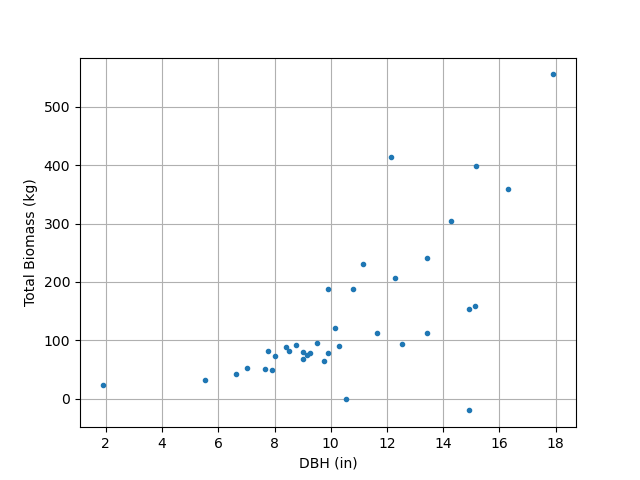

In [49]:
eq = wt.ldata.df.equ == 'BCtimber_Standish'
# pint units really get in the way here
df = wt.ldata.df.loc[eq, ['DBH', 'total_wt', 'Height']].pint.dequantify()

plt.plot(df.DBH, df.total_wt, linestyle='', marker='.')
plt.grid('on')
plt.xlabel('DBH (in)')
plt.ylabel('Total Biomass (kg)')

That's really strange that such large diameter trees have such low biomass. It especially doesn't track with the overall pattern of increasing weight with increasing DBH.

Text(0, 0.5, 'Total Biomass (kg)')

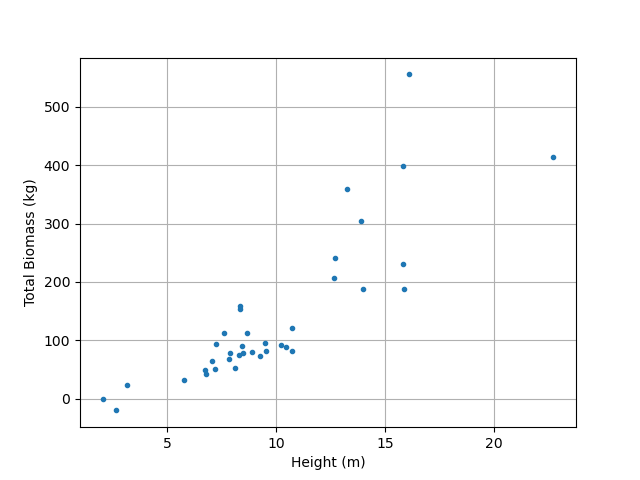

In [52]:
plt.figure()
plt.plot(df.Height, df.total_wt, linestyle='', marker='.')
plt.grid('on')

plt.xlabel('Height (m)')
plt.ylabel('Total Biomass (kg)')

Those tiny heights seem to be dictating the 0 and negative weights, let's double check the raw data and see if there is some sort of error.

In [55]:
pd.options.display.max_columns = 50

In [58]:
wt.ldata.df[wtless]

,Plot,Tree Number,level_2,DBH,Quadrant,Species,spp,DBH/DRC calculated,DBH/DRC,dbh,Unnamed: 8,DBH/DRC Circumfrence (cm),Height,Base reading,Top Reading,Crown Class,Lowest Canopy Height,Lowest Canopy Height Reading,Tree Condition,Distance (M),Stems,spp_eq,equ,total_wt
3,101,4.0,1,10.526784,NW,SW White Pine,PIST3,10.526784,NaN,10.52678363757418 inch,0.0,84.0,2.028,-54.0,50.0,D,0.4485,-31.0,1.0,1.95,NaN,PIMO,BCtimber_Standish,0.0
394,3305,26.0,1,14.912943,SW,Ponderosa Pine,PIPO,14.912943,NaN,14.912943486563421 inch,0.0,119.0,2.625,-57.0,-15.0,NaN,3.5625,NaN,3.0,6.25,NaN,PIPO,BCtimber_Standish,-20.042006


Text(0, 0.5, 'Height (ft)')

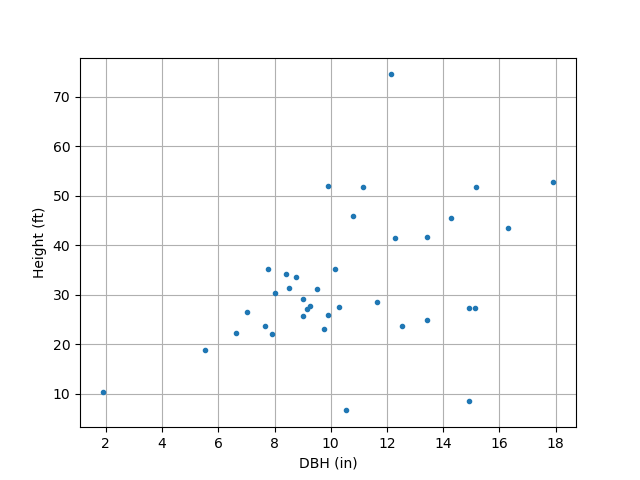

In [67]:
plt.figure()
plt.plot(df.DBH, df.Height*3.28084, linestyle='', marker='.')
plt.grid('on')

plt.xlabel('DBH (in)')
plt.ylabel('Height (ft)')

In [66]:
plt.close(3)